<span style="font-size:10pt">DIADEM course "Deep Learning - Image Classification" / Mai 20-21, 2026<br> 
v1.0  - CC BY-SA 4.0 Jean-Luc CHARLES (Jean-Luc.charles@mailo.com)</span>

<div class="alert alert-block alert-danger">
<span style="color:brown;font-family:arial;font-size:normal">
     It is important to define a <span style="font-weight:bold;">Python Virtual Environment</span> (PVE) for each Python project: 
     a PVE allows you to control the versions of the Python interpreter and “sensitive” modules (tensorflow...) for each project.<br>

- a KAGGLE session can serve as a PVE,
- or if on a local machine, use the `uv` manager to create a PVE and run the notenbook with `uv run jupyter lab` to ensure it uses the PVE of the projet.

<span style="color:maroon; font-family:arial;font-size:1.2cm; font-weight:bold">
    Training a simple Dense Neural Network<br> to classify small MNIST images
</span>    

<p style="color:maroon; font-family:arial; font-size:14pt;">
    In this notebook we use a very simple neural network model to classify the MNIST images to introduce :<br>    
    - the <b>training regularization</b> with the <b>dropout</b> of neuron's weights in the model<br>
    - the mains metrics used to <b>evaluate</b> a model trained to clasiify<br>
    - the <b>cross evaluation</b> approach to give a better evalaution.
</p>    

# Preliminaries

## Configure KAGGLE environment (if needed)

Run the next cell if you run a remote KAGGLE jupyter notebook to configure your kaggle environment.<br>
If you run a local jupyter notebook it wil do nothing.

In [19]:
import os, sys
from pathlib import Path

if 'kaggle' in Path.cwd().as_posix():
    KAGGLE = True
    print(f'Notebook running on KAGGLE')
else:
    KAGGLE = False
    print(f'Notebook not running on KAGGLE')

if KAGGLE:
    #
    # Add the path to the <utils> directory to the sys.path list:
    #
    paths = list(Path('/kaggle').rglob('utils'))
    if len(paths) == 0:
        print('\tNo <utils> directory found in your workspace, sorry.')
    else:
        util_path = paths[0].parent.as_posix()
        sys.path.append(util_path)
        print(f'\t<{util_path}> added to sys.path.')
    
    #
    # Create a link <img> to the image directory of the dataset éDL img"
    #
    img_dataset_path = Path('/kaggle/input/datasets/jlcharles/dl-img')
    link_to_img_dir  = Path.cwd() / 'img'
    if not link_to_img_dir.is_symlink(): 
        link_to_img_dir.symlink_to(img_dataset_path)
    print(f'\tlink <{link_to_img_dir}> to <{img_dataset_path}> OK')

    #
    # import the GPUtil module
    #
    try:
        os.system('pip install GPUtil')
    except OSError as e:
        print("Execution failed:", e, file=sys.stderr)

Notebook not running on KAGGLE


## Import the Python modules

In [20]:
import os
# suppress tensorflow verbose warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Deep Learning modules:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report
from utils.tools import show_conf_matrix

# General modules:
import numpy as np
import matplotlib.pyplot as plt
from time import time
from pathlib import Path
from cpuinfo import get_cpu_info
import GPUtil
import sys
import random
import cv2

# Custom modules:
from utils.tools import scan_dir, elapsed_time_since, cpu_gpu, plot_loss_accuracy

In [21]:
print(f"Python    : {sys.version.split()[0]}")
print(f"tensorflow: {tf.__version__} with keras {keras.__version__}")
print(f"numpy     : {np.__version__}")
print(f"OpenCV    : {cv2.__version__}")

Python    : 3.12.12
tensorflow: 2.19.0 with keras 3.14.0
numpy     : 2.1.3
OpenCV    : 4.13.0


## Set global behaviour

In [22]:
# allows to visualize the graphs directly in the cell of the N.B.
%matplotlib inline

# SEED will be used to fix the _seed_ of the random generators to have continuations
# of repeatable random numbers
SEED = 1234

tf.get_logger().setLevel('ERROR')

## Check wether GPU is available for tensorflow or not:

In [23]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Found {len(gpus)} GPU(s):")
    for gpu in gpus:
        print(f"  - {gpu.name}")
else:
    print("No GPU found, only CPU.")

No GPU found, only CPU.


## Create the `models` directory

In [24]:
print(f'{"WORKING DIRECTORY":20s}: {Path.cwd()}')
model_path = Path("./models")
model_path.mkdir(exist_ok=True)
print(f'{"MODELS DIRECTORY":20s}: {model_path.absolute().as_posix()}')

WORKING DIRECTORY   : /home/jlc/work/IA-MachineLearning/18-DIADEM/DL_DIADEM/Notebooks
MODELS DIRECTORY    : /home/jlc/work/IA-MachineLearning/18-DIADEM/DL_DIADEM/Notebooks/models


# 1 - Prepare the MNIST dataset (images and labels)

## 1.1 Load the MNIST dataset

We use the keras `load_data` function to load the data from the MNIST 
(see [tf.keras.datasets.mnist.load_data](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/mnist/load_data)):<br>
- `train_img`, `train_lab` are the training images and labels,
- `valid_img`, `valid_lab` are the validation images and labels.

In [7]:
(train_img, train_lab), (valid_img, valid_lab) = keras.datasets.mnist.load_data()

Let's check the `shape` and `dtype` attributes of the numpy arrays:

In [8]:
print(f"train_img.shape: {train_img.shape}, dtype: {train_img.dtype}")
print(f"train_lab.shape: {train_lab.shape}, dtype: {train_lab.dtype}")
print(f"valid_img.shape: {valid_img.shape}, dtype: {valid_img.dtype}")
print(f"lab_vaild.shape: {valid_lab.shape}, dtype: {valid_lab.dtype}")

train_img.shape: (60000, 28, 28), dtype: uint8
train_lab.shape: (60000,), dtype: uint8
valid_img.shape: (10000, 28, 28), dtype: uint8
lab_vaild.shape: (10000,), dtype: uint8


## 1.2 Create the 3 datasets: train, validation & test

To follow the _state of the art_, we split the whole dataset into 3 datasets:
- **train dataset**: to train the model,
- **validation dataset**: to evaluate the model after each epoch of training,
- **test dataset**: to finaly evaluate the trained model.<br>

A simple way to do this is to keep the train dataset and to split the current validation dataset in two equal subsets:
- a new smaller validation subset,
- a new test subset.<br>

We use the function `train_test_split` form the `sklearn` module:

In [9]:
from sklearn.model_selection import train_test_split
valid_img, test_img, valid_lab, test_lab = train_test_split(valid_img, valid_lab,
                                                            stratify=valid_lab,
                                                            test_size=0.5,
                                                            shuffle=True,
                                                            random_state=SEED)

Let's check the sizes of the 3 datasets:

In [10]:
print(f'train:  {train_img.shape}')
print(f'valid:  {valid_img.shape}')
print(f'test :  {test_img.shape}')

train:  (60000, 28, 28)
valid:  (5000, 28, 28)
test :  (5000, 28, 28)


## 1.3 Check the quality of the dataset

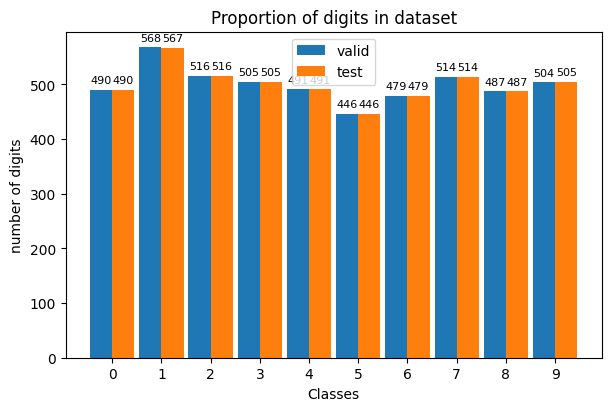

In [11]:
from utils.tools import plot_proportion_bar
prop = {}
prop['valid'] = [ (valid_lab == i).sum() for i in range(10)]
prop['test']  = [ (test_lab  == i).sum() for i in range(10)]
plot_proportion_bar(prop, range(10))

## 1.4 Define important parameters

To avoid hard-coding the number of training, valid and test images as well as the size of the images, these parameters are recovered from the data set:
- with the shape attribute of the `train_img` and `test_im` arrays
- with the size attribute of the first training image for example


In [12]:
NB_TRAIN_IMG = train_img.shape[0]  # number of training images
NB_VALID_IMG = valid_img.shape[0]  # number of validation images 
NB_TEST_IMG  = test_img.shape[0]   # number of test images
NB_PIXEL     = train_img[0].size   # number of elements (pixels) of the firts training image: 
NB_CLASS     = len(set(train_lab)) # number of classes:

# Display checking:
print(f"{NB_TRAIN_IMG} training images, {NB_VALID_IMG} validation images and {NB_TEST_IMG} test images")
print(f"{train_img.shape[1]}x{train_img.shape[2]}={NB_PIXEL} pixels in each image")
print(f"{NB_CLASS} classes found in the `train_lab` ndarray")

60000 training images, 5000 validation images and 5000 test images
28x28=784 pixels in each image
10 classes found in the `train_lab` ndarray


# 2 - Process input data

Two treatments must be applied to the data from the MNIST database:
- **on images**: transform the matrices of  28$\,\times\,$28 pixels (`uint8`integers) into **normalized** vectors $(V_i)_{i=0..783}$ of 784 real values $V_i$ with $ 0 \leqslant V_i \leqslant 1$;
- **on labels**: transform scalar numbers into *one-hot* vectors.

## 2.2 *one-hot* encoding of labels:

## 2.1 - Transform input matrices into normalized vectors

We define the arrays `x_train`, `x_valid` and `x_test` containing the matrices of the arrays `train_img`, `valid_img` and `test_img` *flattened* as normalized vectors (values between 0 and 1):

In [13]:
x_train = train_img.reshape(NB_TRAIN_IMG, NB_PIXEL)/255
x_valid = valid_img.reshape(NB_VALID_IMG, NB_PIXEL)/255
x_test  = test_img.reshape(NB_TEST_IMG, NB_PIXEL)/255

#check:
print(f'train: {x_train.shape}, min: {x_train.min()}, max: {x_train.max()}')
print(f'valid: {x_valid.shape}, min: {x_valid.min()}, max: {x_valid.max()}')
print(f'test : {x_test.shape}, min: {x_test.min()}, max: {x_test.max()}')

train: (60000, 784), min: 0.0, max: 1.0
valid: (5000, 784), min: 0.0, max: 1.0
test : (5000, 784), min: 0.0, max: 1.0


## 2.2 - *one-hot* encoding of labels

We use the **keras** `to_categorical` function (see [tf.keras.utils.to_categorical](https://www.tensorflow.org/api_docs/python/tf/keras/utils/to_categorical)) to define the `y_train` and `y_valid` arrays containing the *hot-one* encoded version of `lab_train` and `lab_valid`:

In [14]:
from tensorflow.keras.utils import to_categorical
# 'one-hot' encoding' of labels :
y_train = to_categorical(train_lab)
y_valid = to_categorical(valid_lab)
y_test  = to_categorical(test_lab)

Let's check the first 10 values of the `lab_train` and `y_train` arrays:

In [15]:
print(train_lab[:10])
print(y_train[:10])

[5 0 4 1 9 2 1 3 1 4]
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


In [16]:
from tensorflow.keras.utils import to_categorical
# 'one-hot' encoding' of labels :
y_train = to_categorical(train_lab)
y_valid = to_categorical(valid_lab)
y_test  = to_categorical(test_lab)

# 3 - Build the Dense Neural Network (DNN)

 We build a simple dense network to classify MNIST images.<br>
 Of course, this is not the "state of the art" : convolutive NN, transformers have much more impressive scores,<br>
 but we just want want a simple model easy to understand with short training computation time.<br><br>
We buildthis naive **dense network**:
- an **input layer** of 784 values (the pixels of the MNIST 28 $\times$ 28 images flattened in the form of a vector of 784 normalized `float` numbers),
- a **hidden layer** of 100 neurons using the `relu` activation function,
- an **output layer** of 10 neurons, for the classification of the 10 digits {0,1,2...9}, using the `softmax` activation function adapted to classification problems .

<p style="text-align:center; font-style:italic; font-size:12px;">
      <img src="img/Simple-DNN.png" alt="Simple-DNN.png" style="width:900px;"><br>
     [image credit: JLC]

In [27]:
NB_NEURON = NB_PIXEL

For the sake of convenience we défine a function to build the NN: 

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout

def build_DNN(nb_input, nb_neuron, nb_class, dropout, seed=None, name=''):

    if seed is not None:
        ##########################
        # Deterministic training #
        ##########################
        # 1/ set the seed of the random generators involved by tensorflow:
        tf.keras.utils.set_random_seed(seed)
        # 2/ make the tf ops determinisctic 
        # [see https://blog.tensorflow.org/2022/05/whats-new-in-tensorflow-29.html]
        tf.config.experimental.enable_op_determinism() 

    model = Sequential()
    model.add(Input(shape=(nb_input,), name='input'))                # INPUT layer
    model.add(Dropout(dropout, seed=seed))                           # drop out 
    model.add(Dense(nb_neuron, activation='relu', name='c1'))        # First hidden layer
    model.add(Dense(nb_class, activation='softmax', name='output'))  # OUTPUT layer
    
    model.compile(loss='categorical_crossentropy', optimizer='adam',  metrics=['accuracy'])
    
    if name: model.name = name
    return model

Lets's look at the number of _parameters_ (the _weights_) of the model:

In [40]:
SEED    = 1234
DROPOUT = 0.3

model = build_DNN(NB_PIXEL, NB_NEURON, NB_CLASS, dropout=DROPOUT, seed=SEED)
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_3 (Dropout)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c1 (Dense)                      │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 623,290 (2.38 MB)

 Trainable params: 623,290 (2.38 MB)

 Non-trainable params: 0 (0.00 B)

# 4 - Reproducible training of the model, avoiding overfit

## 4.1 Avoiding **over-fit** with **early-stop** of the training

Overfitting occurs when the model is trained too well on the training data but poorly performs on new unseen data. That kind of model tries to memorize the training data and fails to generalize on new unseen data.

Keras offers tools to automatically stop learning by monitoring for example the growth of `val_accuracy` or the decrease of `val_loss` from one epoch to another (see the _EarlyStopping_ callback).

We can thus define a list of callback functions that we pass as an argument to the `fit` method with the agument named _callbacks_:

In [45]:
SEED    = 1234
DROPOUT = 0.3

model = build_DNN(NB_PIXEL, NB_NEURON, NB_CLASS, dropout=DROPOUT, seed=1234)

model_file = f'models/DNN_seed-{SEED}_drop-{DROPOUT}_init.keras'
print(f'saving model & weights in <{model_file}>')

model.save(model_file)

saving model & weights in <models/DNN_seed-1234_drop-0.3_init.keras>


loading model & weights from <models/DNN_seed-1234_drop-0.3_init.keras>
Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9238 - loss: 0.2485 - val_accuracy: 0.9646 - val_loss: 0.1204
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9633 - loss: 0.1171 - val_accuracy: 0.9754 - val_loss: 0.0806
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9706 - loss: 0.0907 - val_accuracy: 0.9770 - val_loss: 0.0774
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9761 - loss: 0.0727 - val_accuracy: 0.9794 - val_loss: 0.0701
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9799 - loss: 0.0616 - val_accuracy: 0.9802 - val_loss: 0.0672
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9817 - loss: 0.0555 - val_accuracy: 0.9822 - val_loss: 0.0611
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9833 - loss: 0.0499 - val_accuracy: 0.9802 - val_loss: 0.0679
Epoch 8/25
1875/18

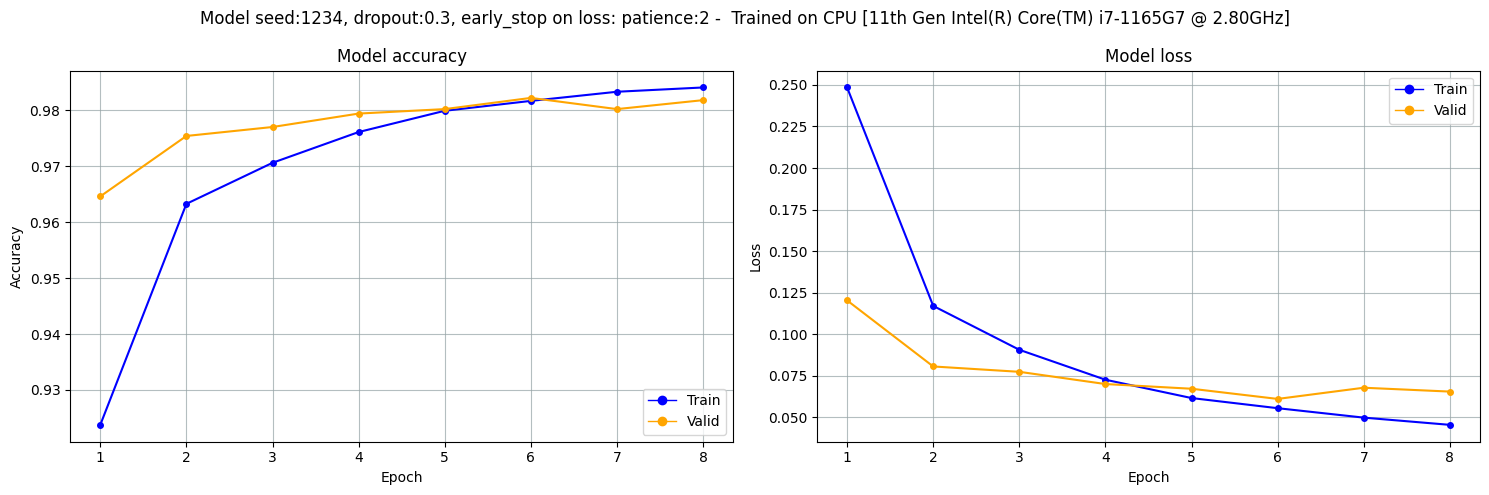

In [46]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from utils.tools import plot_loss_accuracy

PATIENCE = 2

# define the list of 'callback' fucntions:
callbacks_list = [
    EarlyStopping(monitor='val_loss',  # The parameter to monitor
                  patience=PATIENCE,   # accept that 'val_accuracy' decrease 'patience' times
                  restore_best_weights=True,
                  verbose=1)
]

# load the network structure & initial weights:
model_file = f'models/DNN_seed-{SEED}_drop-{DROPOUT}_init.keras'
print(f'loading model & weights from <{model_file}>')

model = tf.keras.models.load_model(f'models/DNN_seed-{SEED}_drop-{DROPOUT}_init.keras')

# Deterministic tensorflow training: 
tf.keras.utils.set_random_seed(1234)  # sets seeds for base-python, numpy and tf
tf.config.experimental.enable_op_determinism() 

hist = model.fit(x_train, y_train,
                 validation_data=(x_valid, y_valid), 
                 epochs=25,     # the total number of successive trainings
                 batch_size=32, # fragmentation of the whole dada set in batches
                 callbacks = callbacks_list)
plot_loss_accuracy(hist, message=f'Model seed:{SEED}, dropout:{DROPOUT}, early_stop on loss: patience:{PATIENCE}')

## 4.2 Save the trained model

In [47]:
trained_model_file = f'models/DNN_seed-{SEED}_drop-{DROPOUT}_trained.keras'
print(f'saving trained model & weights in <{trained_model_file}>')

model.save(trained_model_file)

saving trained model & weights in <models/DNN_seed-1234_drop-0.3_trained.keras>


# 5 - Simple evaluation of the trained model

## 5.1 Load the structure and weights of a trained model:

In [48]:
print(f'loading trained model & weights from <{trained_model_file}>')

model = tf.keras.models.load_model(trained_model_file)

loading trained model & weights from <models/DNN_seed-1234_drop-0.3_trained.keras>


## 5.1 Compute the predictions of the model:

In [58]:
# Predicting labels for test images
test_pred = model.predict(x_test)

# transform the one-hot vectors into scalars:
pred_lab = np.argmax(test_pred, axis=-1)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


## 5.2 Model `accuracy`

`Accuracy` is a global metric quantifying the percentage of correct predictions a model makes relative to the total number of predictions.

In the context of machine learning (and specifically supervised learning), this metric provides a high-level snapshot of how effectively an algorithm aligns with the *ground truth* provided during the training process. 

It is the most intuitive measure of performance answering the question "How often is the model right?" and is often used as first indicator before diving into more granular metrics. 

#### Direct calculation

In [70]:
nb_true_pred = (pred_lab == test_lab).sum()    # The number of true predictions on the test dataset
nb_test_lab  = len(test_lab)                   # The total number of labels in the test dataset
print(f'{nb_true_pred} true predictions over {nb_test_lab} test labels => accuracy = {100*nb_true_pred/nb_test_lab:.2f}%')

4917 true predictions over 5000 test labels => accuracy = 98.34%


#### Using the `evaluate` method of the model: 

In [71]:
# evaluate the model with the test dataset: 
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

157/157 - 0s - 2ms/step - accuracy: 0.9834 - loss: 0.0574


## 5.3 Precision, Recall and F1-score

**Precision**<br>
measures the quality of positive predictions.<br>
$\displaystyle{\mathrm{Precision}=\frac{tp}{tp + fp}}$ where $tp$ is the number of *true positives* and $fp$ the number of *false positives*.<br>
The precision is intuitively the ability of the classifier not to label a negative sample as positive.<br>
When does Precision matter most? When a False Positive is costly.

**Recall**<br>
The recall is intuitively the ability of the classifier to find all the positive samples.<br>
is the ratio $\displaystyle{\frac{tp}{tp + fn}}$ where $tp$ is the number of *true positives* and $fn$ the number of *false negatives*.<br>
High Recall $\leadsto$ the model is thorough. It tries not to miss anything.<br>
When does Recall matter most? When a False Negative is costly.

**F1-score** <br> 

F1-score can be interpreted as a weighted harmonic mean of the precision and recall, where an F$_\beta$-score reaches its best value at 1 and worst score at 0.<br>
$F1-score = \frac{presion \times recall}{precision + recall}$<br>
The F1-score weights recall more than precision by a factor of $\displaystyle{F1}$ == 1.0 means recall and precision are equally important.<br>
When to use F1: When working with unbalanced data and want a single number to compare different models, without ignoring either type of error.

The support is the number of occurrences of each class in y_true.

In [74]:
# Display classification report using the 'classification_repport' function from sklearn:
print("Classification Report:\n", classification_report(test_lab, predict_labels))

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       490
           1       0.99      0.99      0.99       567
           2       0.99      0.98      0.98       516
           3       0.97      0.98      0.98       505
           4       0.99      0.97      0.98       491
           5       0.99      0.99      0.99       446
           6       1.00      0.97      0.99       479
           7       0.98      0.98      0.98       514
           8       0.98      0.98      0.98       487
           9       0.97      0.99      0.98       505

    accuracy                           0.98      5000
   macro avg       0.98      0.98      0.98      5000
weighted avg       0.98      0.98      0.98      5000



## 5.4 Confusion matrix

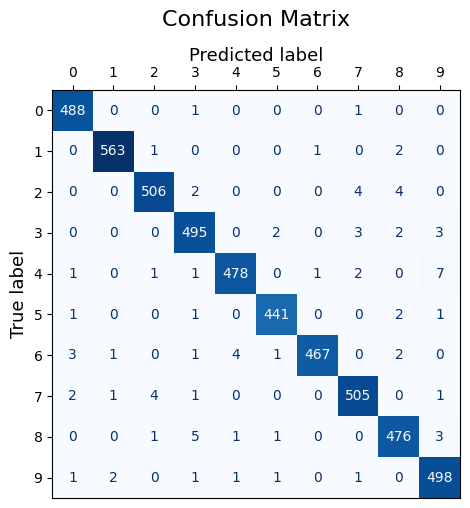

In [50]:
show_conf_matrix(test_lab, predict_labels, range(NB_CLASS), figsize=(7,6));

True Positive: &emsp; $\mathrm{TP}(k) = M(k,k)$  

False Positives: &emsp; $\mathrm{FP}(k) = \sum_{i \ne k} M(i,k)$

True Negatives: &emsp; $\mathrm{TN}(k) = \sum_{j \ne k} M(k, j)$

 Precision: &emsp; $\displaystyle{\mathrm{P}(k) = \frac{\mathrm{TP}(k)}{\mathrm{TP}(k) + \mathrm{FP}(k)}}$
&emsp;&emsp;&emsp;Recall: &emsp; $\displaystyle{\mathrm{P}(k) = \frac{\mathrm{TP}(k)}{\mathrm{TP}(k) + \mathrm{FP}(k)}}$